# Projet : Prédiction de la maladie cardiaque avec régression logistique

## 1. Import des librairies nécessaires


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 2. Chargement des données


In [2]:
# Remplace par ton chemin local exact
file_path = r"C:\Users\isaac\Documents\Pst&b\Bootcamp\S4\J5\UCI Heart Disease Data\heart_disease_uci.csv"

df = pd.read_csv(file_path)
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Exploration des données (EDA)

- Afficher la taille du dataset
- Statistiques descriptives
- Types de données
- Rechercher les valeurs manquantes


In [3]:
print(f"Dimensions du dataset : {df.shape}")
print("\nTypes des colonnes :")
print(df.dtypes)
print("\nStatistiques descriptives :")
print(df.describe())
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Dimensions du dataset : (920, 16)

Types des colonnes :
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Statistiques descriptives :
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250

## 4. Visualisations simples

- Histogrammes des variables numériques
- Distribution de la cible


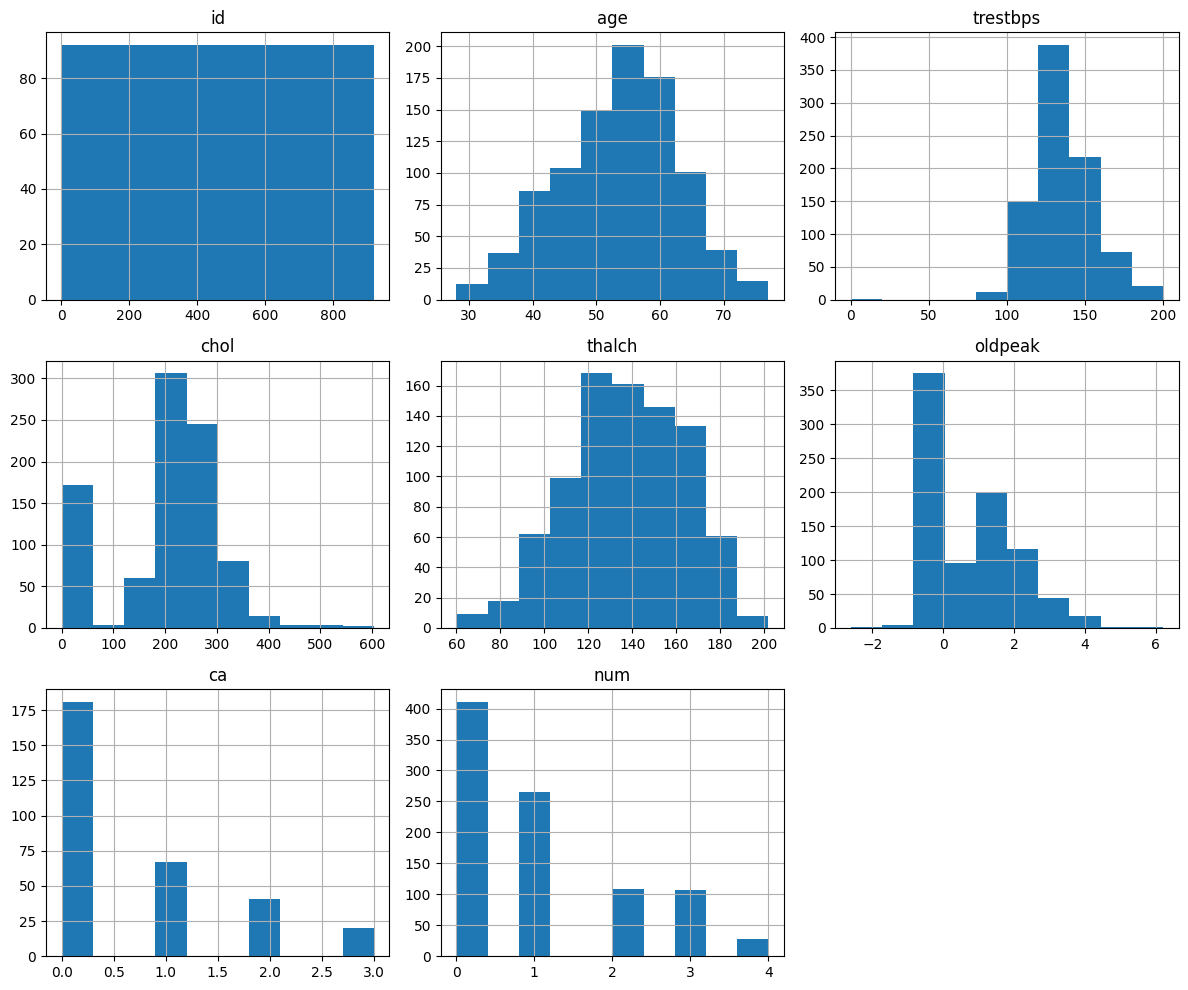

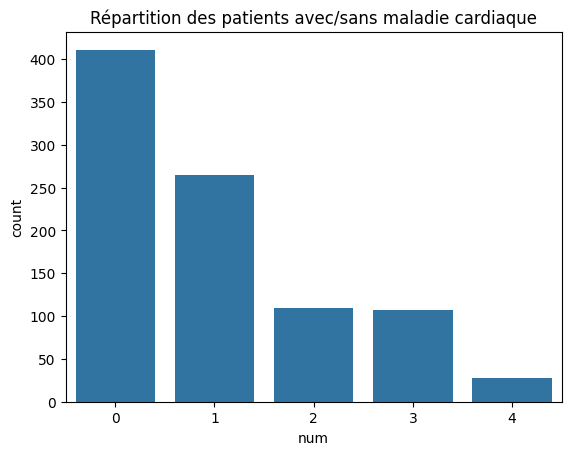

In [5]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

sns.countplot(x='num', data=df)
plt.title('Répartition des patients avec/sans maladie cardiaque')
plt.show()


## 5. Préparation des données

- Séparation des variables explicatives (X) et cible (y)
- Identification des colonnes numériques et catégorielles
- Traitement des valeurs manquantes
- Encodage des variables catégorielles
- Mise à l’échelle des variables numériques


In [8]:
# Création de la variable cible binaire : 1 si num > 0, sinon 0
df['target'] = (df['num'] > 0).astype(int)

# Supprimer 'num' et 'target' de X, garder 'target' dans y
X = df.drop(['num', 'target'], axis=1)
y = df['target']

# Identification des colonnes numériques (int, float) et catégorielles (object)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Colonnes numériques : {num_cols}")
print(f"Colonnes catégorielles : {cat_cols}")

# Pipeline pour colonnes numériques : imputation + scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour colonnes catégorielles : imputation + one-hot encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines dans un transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Retirer 'id' des colonnes numériques car ce n'est pas une feature utile
num_cols.remove('id')

print(f"Colonnes numériques corrigées : {num_cols}")


Colonnes numériques : ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Colonnes catégorielles : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Colonnes numériques corrigées : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


## 6. Division des données en train/test


In [9]:
from sklearn.model_selection import train_test_split

# Division stratifiée pour garder la même proportion de malades/non-malades dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille du train : {X_train.shape[0]} | Taille du test : {X_test.shape[0]}")


Taille du train : 736 | Taille du test : 184


## 7. Création du pipeline complet : prétraitement + régression logistique


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pipeline complet avec préprocessing et modèle
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


## 8. Entraînement du modèle


In [11]:
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 9. Évaluation du modèle


Accuracy : 0.8370
Precision : 0.8273
Recall : 0.8922
F1 Score : 0.8585


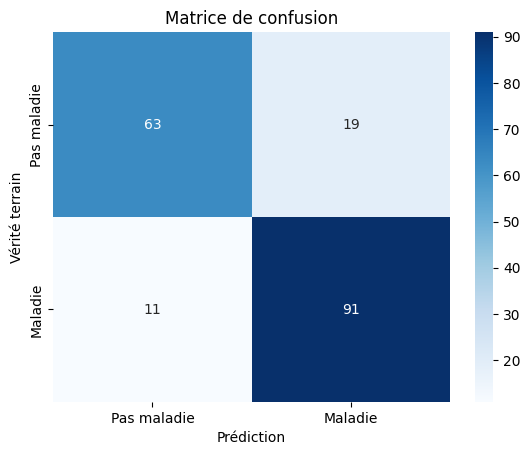


Rapport de classification :

              precision    recall  f1-score   support

 Pas maladie       0.85      0.77      0.81        82
     Maladie       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions sur le test
y_pred = model_pipeline.predict(X_test)

# Calcul des métriques
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pas maladie', 'Maladie'], yticklabels=['Pas maladie', 'Maladie'])
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()

# Rapport de classification détaillé
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=['Pas maladie', 'Maladie']))


Analyse de la matrice de confusion
Prédit : Pas maladie	Prédit : Maladie
Vérité : Pas maladie	63 (vrais négatifs)	19 (faux positifs)
Vérité : Maladie	11 (faux négatifs)	91 (vrais positifs)

Vrais positifs (TP) : 91 — bonnes détections des malades

Faux négatifs (FN) : 11 — malades non détectés (risque)

Vrais négatifs (TN) : 63 — bonnes détections des non-malades

Faux positifs (FP) : 19 — non-malades mal classés

Indicateurs clés
Accuracy (Précision globale) : 83.7%

Precision (Précision sur la classe Maladie) : 82.7%

Recall (Rappel, sensibilité) : 89.2% — très bon, peu de malades non détectés

F1-score : 85.8% — bon équilibre entre précision et rappel

Conclusion
Le modèle est efficace pour détecter la maladie, avec un bon compromis entre erreurs de type faux positifs et faux négatifs.

Le rappel élevé est crucial en santé pour ne pas manquer trop de malades.

Le score F1 confirme un bon équilibre global.

In [ ]:
!git add .
!git commit -m " Préprocessing, Modélisation et Évaluation"
!git push origin main